<a href="https://colab.research.google.com/github/RazorXDK/ExamenPython/blob/main/Practica_Guiada.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Nombres de todas las columnas:
['MODELYEAR', 'MAKE', 'MODEL', 'VEHICLECLASS', 'ENGINESIZE', 'CYLINDERS', 'TRANSMISSION', 'FUELTYPE', 'FUELCONSUMPTION_CITY', 'FUELCONSUMPTION_HWY', 'FUELCONSUMPTION_COMB', 'FUELCONSUMPTION_COMB_MPG', 'CO2EMISSIONS']

Primeras filas:
   ENGINESIZE  CYLINDERS  FUELCONSUMPTION_COMB  CO2EMISSIONS
0         2.0          4                   8.5           196
1         2.4          4                   9.6           221
2         1.5          4                   5.9           136
3         3.5          6                  11.1           255
4         3.5          6                  10.6           244

Estadísticas descriptivas:
        ENGINESIZE    CYLINDERS  FUELCONSUMPTION_COMB  CO2EMISSIONS
count  1067.000000  1067.000000           1067.000000   1067.000000
mean      3.346298     5.794752             11.580881    256.228679
std       1.415895     1.797447              3.485595     63.372304
min       1.000000     3.000000              4.700000    108.000000
2

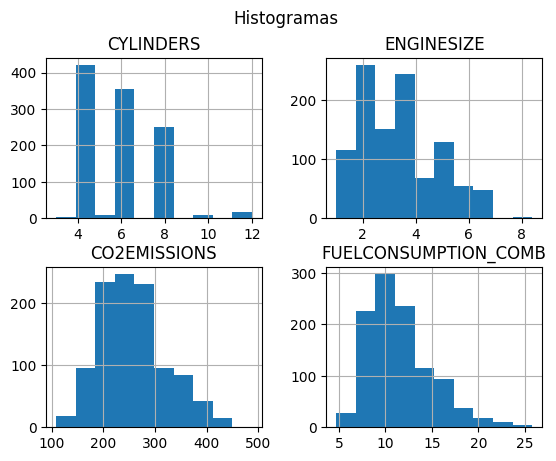

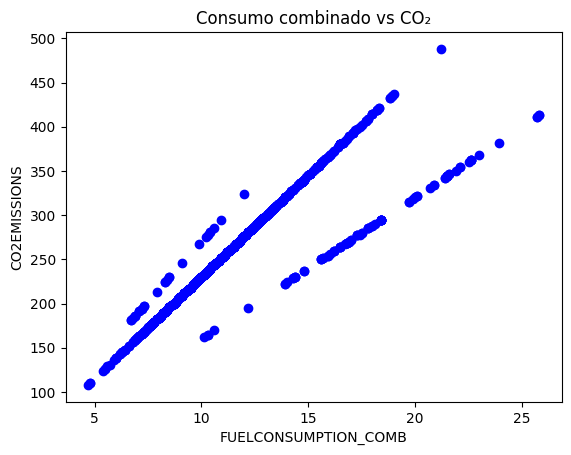

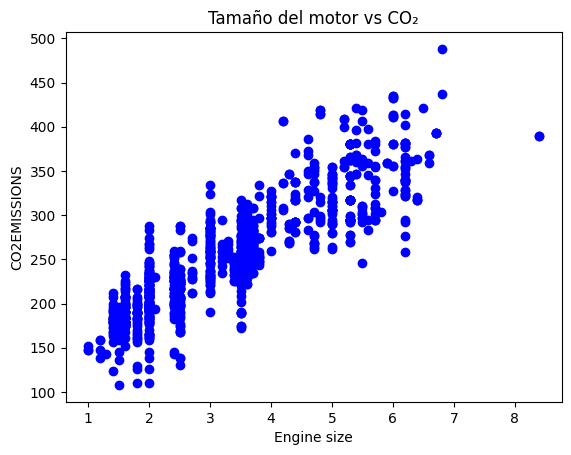

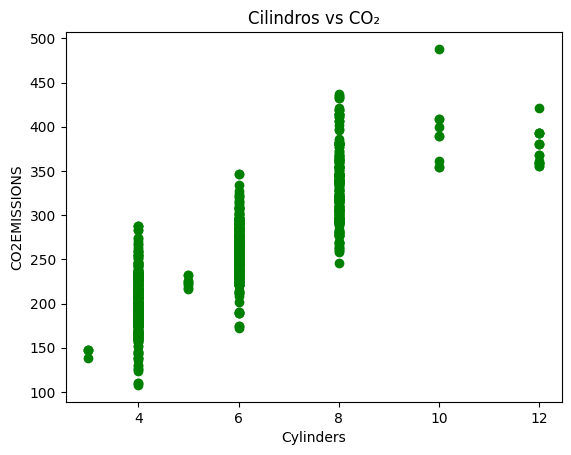


--- Regresión Lineal Simple ---
Coeficiente: 39.53
Intercepto: 124.18


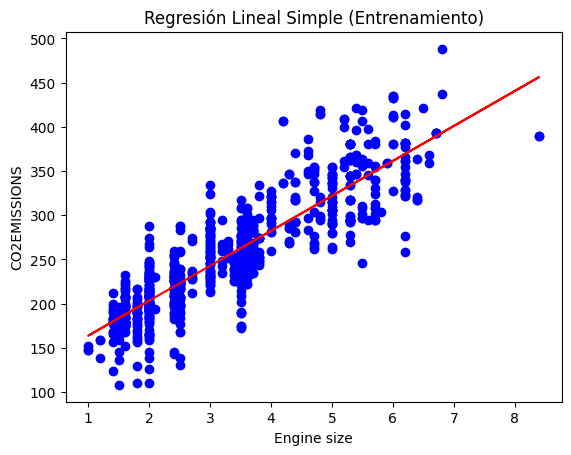


Métricas del modelo simple en test:
MAE: 22.58
MSE: 851.05
R²: 0.78

--- RETO 1: K-Fold Cross Validation (Polinomial) ---
Grado 1: MSE = 951.19 (±78.73), R² = 0.7618
Grado 2: MSE = 943.39 (±77.46), R² = 0.7638
Grado 3: MSE = 939.85 (±74.97), R² = 0.7647
Grado 4: MSE = 940.41 (±75.54), R² = 0.7645
Grado 5: MSE = 941.43 (±74.38), R² = 0.7643

--- RETO 2: Regresión Lineal Múltiple ---
Coeficientes: [11.2094395   7.15561381  9.5208118 ]
Intercepto: 67.3483851836209
MAE: 16.72
MSE: 512.86
R²: 0.88

Columnas numéricas disponibles para el análisis: ['MODELYEAR', 'ENGINESIZE', 'CYLINDERS', 'FUELCONSUMPTION_CITY', 'FUELCONSUMPTION_HWY', 'FUELCONSUMPTION_COMB', 'FUELCONSUMPTION_COMB_MPG']

--- RETO 3: Resumen statsmodels ---
                            OLS Regression Results                            
Dep. Variable:           CO2EMISSIONS   R-squared:                       0.889
Model:                            OLS   Adj. R-squared:                  0.889
Method:                 Least Squares

In [3]:
# -*- coding: utf-8 -*-
"""Práctica Guiada: Regresión Lineal Simple y Múltiple (Mario Roberto Grajeda)"""

# 1. Importar paquetes
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn import linear_model
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.model_selection import KFold, cross_val_score, train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
import statsmodels.api as sm

# 2. Cargar datos
url = "https://s3-api.us-geo.objectstorage.softlayer.net/cf-courses-data/CognitiveClass/ML0101ENv3/labs/FuelConsumptionCo2.csv"
df = pd.read_csv(url)
print("Nombres de todas las columnas:")
print(df.columns.tolist())

# 3. Seleccionar características conocidas y explorar
cdf = df[['ENGINESIZE','CYLINDERS','FUELCONSUMPTION_COMB','CO2EMISSIONS']]
print("\nPrimeras filas:")
print(cdf.head())
print("\nEstadísticas descriptivas:")
print(cdf.describe())

# Histogramas
cdf[['CYLINDERS','ENGINESIZE','CO2EMISSIONS','FUELCONSUMPTION_COMB']].hist()
plt.suptitle("Histogramas")
plt.show()

# Relaciones
plt.scatter(cdf.FUELCONSUMPTION_COMB, cdf.CO2EMISSIONS, color='blue')
plt.xlabel("FUELCONSUMPTION_COMB")
plt.ylabel("CO2EMISSIONS")
plt.title("Consumo combinado vs CO₂")
plt.show()

plt.scatter(cdf.ENGINESIZE, cdf.CO2EMISSIONS, color='blue')
plt.xlabel("Engine size")
plt.ylabel("CO2EMISSIONS")
plt.title("Tamaño del motor vs CO₂")
plt.show()

plt.scatter(cdf.CYLINDERS, cdf.CO2EMISSIONS, color='green')
plt.xlabel("Cylinders")
plt.ylabel("CO2EMISSIONS")
plt.title("Cilindros vs CO₂")
plt.show()

# 4. Regresión lineal simple (ENGINESIZE -> CO2EMISSIONS)
np.random.seed(42)
msk = np.random.rand(len(df)) < 0.8
train = cdf[msk]
test = cdf[~msk]

regr = linear_model.LinearRegression()
train_x = np.asanyarray(train[['ENGINESIZE']])
train_y = np.asanyarray(train[['CO2EMISSIONS']])
regr.fit(train_x, train_y)
print("\n--- Regresión Lineal Simple ---")
print("Coeficiente: {:.2f}".format(regr.coef_[0][0]))
print("Intercepto: {:.2f}".format(regr.intercept_[0]))

# Gráfico de la recta
plt.scatter(train.ENGINESIZE, train.CO2EMISSIONS, color='blue')
plt.plot(train_x, regr.coef_[0][0]*train_x + regr.intercept_[0], '-r')
plt.xlabel("Engine size")
plt.ylabel("CO2EMISSIONS")
plt.title("Regresión Lineal Simple (Entrenamiento)")
plt.show()

# Evaluación
test_x = np.asanyarray(test[['ENGINESIZE']])
test_y = np.asanyarray(test[['CO2EMISSIONS']])
test_y_ = regr.predict(test_x)
print("\nMétricas del modelo simple en test:")
print("MAE: {:.2f}".format(mean_absolute_error(test_y, test_y_)))
print("MSE: {:.2f}".format(mean_squared_error(test_y, test_y_)))
print("R²: {:.2f}".format(r2_score(test_y, test_y_)))

# 5. RETO 1: K-Fold Cross Validation (grado polinómico)
X_poly = cdf[['ENGINESIZE']].values
y_poly = cdf['CO2EMISSIONS'].values
kfold = KFold(n_splits=5, shuffle=True, random_state=42)
print("\n--- RETO 1: K-Fold Cross Validation (Polinomial) ---")
for d in range(1, 6):
    model = make_pipeline(PolynomialFeatures(d), linear_model.LinearRegression())
    mse = -cross_val_score(model, X_poly, y_poly, cv=kfold, scoring='neg_mean_squared_error')
    r2 = cross_val_score(model, X_poly, y_poly, cv=kfold, scoring='r2')
    print(f"Grado {d}: MSE = {mse.mean():.2f} (±{mse.std():.2f}), R² = {r2.mean():.4f}")

# 6. RETO 2: Regresión Lineal Múltiple (con las 3 variables originales)
features = ['ENGINESIZE', 'CYLINDERS', 'FUELCONSUMPTION_COMB']
X_mult = cdf[features]
y_mult = cdf['CO2EMISSIONS']
X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(X_mult, y_mult, test_size=0.2, random_state=42)
model_mult = linear_model.LinearRegression()
model_mult.fit(X_train_m, y_train_m)
y_pred_m = model_mult.predict(X_test_m)

print("\n--- RETO 2: Regresión Lineal Múltiple ---")
print("Coeficientes:", model_mult.coef_)
print("Intercepto:", model_mult.intercept_)
print("MAE: {:.2f}".format(mean_absolute_error(y_test_m, y_pred_m)))
print("MSE: {:.2f}".format(mean_squared_error(y_test_m, y_pred_m)))
print("R²: {:.2f}".format(r2_score(y_test_m, y_pred_m)))

# 7. RETO 3: Variables poco significativas (usando todas las columnas numéricas disponibles)
# Excluir la columna objetivo y cualquier columna no numérica
all_numeric = df.select_dtypes(include=[np.number]).columns.tolist()
if 'CO2EMISSIONS' in all_numeric:
    all_numeric.remove('CO2EMISSIONS')
print("\nColumnas numéricas disponibles para el análisis:", all_numeric)

# Si no hay ninguna, usar al menos ENGINESIZE, CYLINDERS, FUELCONSUMPTION_COMB
if len(all_numeric) == 0:
    all_numeric = ['ENGINESIZE', 'CYLINDERS', 'FUELCONSUMPTION_COMB']

X_all = df[all_numeric]
X_all = sm.add_constant(X_all)
model_sm = sm.OLS(df['CO2EMISSIONS'], X_all).fit()
print("\n--- RETO 3: Resumen statsmodels ---")
print(model_sm.summary())

print("\nVariables con p-valor > 0.05 (posiblemente poco significativas):")
for var, pval in zip(['const'] + all_numeric, model_sm.pvalues):
    if pval > 0.05:
        print(f"  - {var}: p = {pval:.4f}")